# Proper Orthogonal Decomposition for Reduced-Order Modeling of the Diffusion Equation

This notebook presents the complete construction of a Reduced-Order Model (ROM)
for the two-dimensional diffusion equation using Proper Orthogonal Decomposition (POD).

The workflow consists of

1. solving the full-order finite element model,
2. collecting solution snapshots,
3. extracting the POD basis,
4. constructing the Galerkin reduced-order model,
5. comparing the reduced solution with the full-order solution.

The implementation relies on FEniCSx for the finite element discretization
and NumPy for the linear algebra operations.

---


# 0. Imports

In [2]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem, assemble_matrix
import ufl
import time

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


---

# 1. Problem Definition

We consider the transient diffusion equation on the unit square

$$
\Omega = (0,1)^2.
$$

The governing equation is

$$
\frac{\partial u}{\partial t}
-
\nu \Delta u
=
0,
\qquad
\text{in }
\Omega \times (0,T],
$$

subject to homogeneous Dirichlet boundary conditions

$$
u = 0
\qquad
\text{on }
\partial\Omega,
$$

and the initial condition

$$
u(x,y,0)=u_0(x,y).
$$

Throughout this notebook, the diffusion coefficient is chosen as

$$
\nu = 10^{-2}.
$$

This equation serves as the Full Order Model (FOM) from which the reduced-order model will later be constructed using Proper Orthogonal Decomposition (POD).

## Physical and Numerical Parameters

In [3]:
# Physical parameters
nu = 1.0e-2
T = 0.5

# Time discretization
num_steps = 200
dt = T / num_steps

# Spatial discretization
nx = 30
ny = 30

## Computational Mesh
The computational domain is discretized using a structured triangular mesh generated by FEniCSx.

In [4]:
comm = MPI.COMM_WORLD

domain = mesh.create_unit_square(comm, nx, ny)

## Finite Element Space
The solution is approximated using continuous piecewise-linear Lagrange finite elements (P1).

In [5]:
V = fem.functionspace(
    domain,
    ("CG", 1),
)

In [6]:
coords = V.tabulate_dof_coordinates()[:, :2]
triangulation = mtri.Triangulation(coords[:, 0], coords[:, 1])

## Boundary Conditions
We impose homogeneous Dirichlet boundary conditions on the entire boundary of the computational domain,

$$
u = 0
\qquad
\text{on }
\partial\Omega.
$$

In FEniCSx, boundary conditions are applied by first locating the boundary facets, then identifying the associated degrees of freedom.

In [7]:
# Topological dimension of the boundary
fdim = domain.topology.dim - 1

# Locate all boundary facets
boundary_facets = mesh.locate_entities_boundary(
    domain,
    fdim,
    lambda x: np.full(x.shape[1], True, dtype=bool),
)

# Locate the corresponding degrees of freedom
boundary_dofs = fem.locate_dofs_topological(
    V,
    fdim,
    boundary_facets,
)

# Homogeneous Dirichlet boundary condition
bc = fem.dirichletbc(
    PETSc.ScalarType(0.0),
    boundary_dofs,
    V,
)

## Trial and Test Functions
The finite element approximation is obtained by solving the weak formulation of the diffusion equation.

We therefore introduce

- a **trial function**, representing the unknown solution,
- a **test function**, belonging to the same finite element space.

In [8]:
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

## Solution Fields
Two finite element functions are introduced:

- `u_prev` stores the solution at the previous time step;
- `u_curr` stores the solution at the current time step.

In [9]:
u_prev = fem.Function(V)      # solution at time tⁿ
u_curr = fem.Function(V)      # solution at time tⁿ⁺¹

### Initial Condition

The initial condition is chosen as

$$
\begin{aligned}
u_0(x,y)=&
\sin(\pi x)\sin(\pi y)
+\frac{1}{2}\sin(2\pi x)\sin(3\pi y)\\
&+\frac{1}{3}\sin(4\pi x)\sin(2\pi y)
+\frac{1}{4}\sin(3\pi x)\sin(5\pi y)\\
&+\frac{1}{5}\sin(6\pi x)\sin(4\pi y).
\end{aligned}
$$

This smooth multi-frequency field satisfies the homogeneous Dirichlet boundary
conditions while exciting several spatial eigenmodes of the Laplacian.

As the diffusion equation evolves, the higher spatial frequencies decay more
rapidly than the lower ones, producing a richer set of snapshots. This makes
the example more representative of practical reduced-order modeling problems
and provides a more informative POD spectrum.

In [10]:
def initial_condition(x):
    """Smooth multi-frequency initial condition."""

    return (
        np.sin(np.pi * x[0]) * np.sin(np.pi * x[1])
        + 0.5
        * np.sin(2.0 * np.pi * x[0])
        * np.sin(3.0 * np.pi * x[1])
        + (1.0 / 3.0)
        * np.sin(4.0 * np.pi * x[0])
        * np.sin(2.0 * np.pi * x[1])
        + 0.25
        * np.sin(3.0 * np.pi * x[0])
        * np.sin(5.0 * np.pi * x[1])
        + 0.20
        * np.sin(6.0 * np.pi * x[0])
        * np.sin(4.0 * np.pi * x[1])
    )

In [11]:
u_prev.interpolate(initial_condition)
u_prev.x.scatter_forward()

## Variational Formulation

Using the backward Euler method, the weak formulation at each time step is

$$
\int_\Omega
u^{n+1}v\,dx
+
\Delta t\,\nu
\int_\Omega
\nabla u^{n+1}\cdot\nabla v\,dx
=
\int_\Omega
u^{n}v\,dx.
$$

The corresponding bilinear and linear forms are defined below using the Unified Form Language (UFL).

---

# 2. Full-Order Model (FOM)

In [12]:
# Bilinear form
a = (
    u * v
    + dt * nu * ufl.inner(ufl.grad(u), ufl.grad(v))
) * ufl.dx

# Linear form
L = (
    u_prev * v
) * ufl.dx

## Linear Solver

Since the variational problem is linear, we rely on the high-level `LinearProblem`
interface provided by FEniCSx.

The linear system is solved using a direct LU factorization.

In [13]:
problem = LinearProblem(
    a,
    L,
    petsc_options_prefix="diffusion_",
    bcs=[bc],
    u=u_curr,
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
)

## Snapshot Generation
The Full Order Model is solved over the entire time interval.

At each time step, the finite element solution is stored in order to build the snapshot matrix used later for POD.

In [14]:
snapshots = []

def solution_vector(function):
    """
    Return the degrees of freedom of a finite element function
    as a NumPy array.
    """
    function.x.scatter_forward()
    return function.x.array.copy()

# Store the initial condition
snapshots.append(solution_vector(u_prev))

for _ in range(num_steps):

    # Solve the variational problem
    problem.solve()

    # Store the current solution
    snapshots.append(solution_vector(u_curr))

    # Update the previous solution
    u_prev.x.array[:] = u_curr.x.array
    u_prev.x.scatter_forward()

## Snapshot Matrix
The snapshots are assembled into a matrix

$$
S =
\begin{bmatrix}
| & | & & | \\
u^0 & u^1 & \cdots & u^{N_s} \\
| & | & & |
\end{bmatrix},
$$

where each column corresponds to one finite element solution at a given time step.

In [15]:
S = np.column_stack(snapshots)

print(f"Snapshot matrix shape: {S.shape}")

Snapshot matrix shape: (961, 201)


## First Inspection
Before constructing the reduced basis, we verify that the snapshots have been generated successfully.

In [16]:
print(f"Number of degrees of freedom : {S.shape[0]}")
print(f"Number of snapshots          : {S.shape[1]}")

Number of degrees of freedom : 961
Number of snapshots          : 201


## Visualization of the Full-Order Model

Before constructing the reduced-order model, we inspect a few snapshots of the finite element solution.

This helps verify that the full-order simulation behaves as expected.

In [17]:
def plot_snapshot(values, title, filename=None):
    fig, ax = plt.subplots(figsize=(6, 5))

    pc = ax.tripcolor(
        triangulation,
        values,
        shading="gouraud",
        cmap="viridis",
    )
    ax.triplot(triangulation, color="k", lw=0.2, alpha=0.25)
    fig.colorbar(pc, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

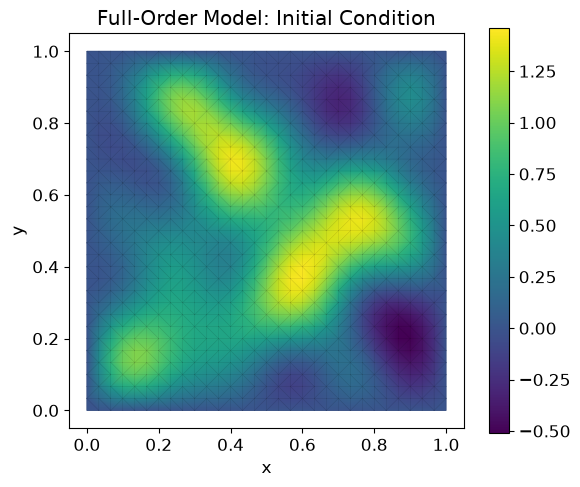

In [18]:
plot_snapshot(
    S[:, 0],
    "Full-Order Model: Initial Condition",
    "snapshot_initial.png"
)

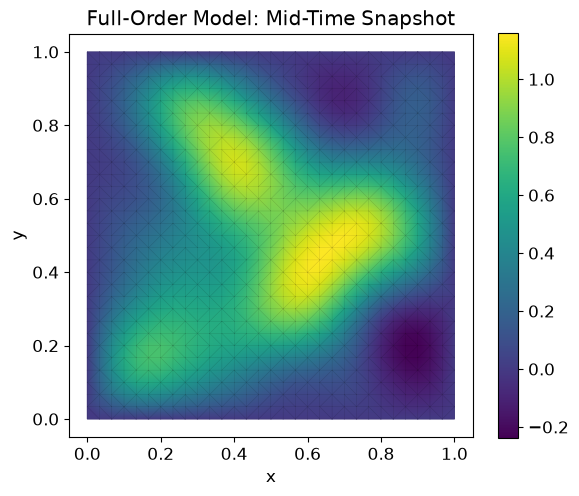

In [19]:
plot_snapshot(S[:, S.shape[1] // 2], "Full-Order Model: Mid-Time Snapshot", "snapshot_mid.png")

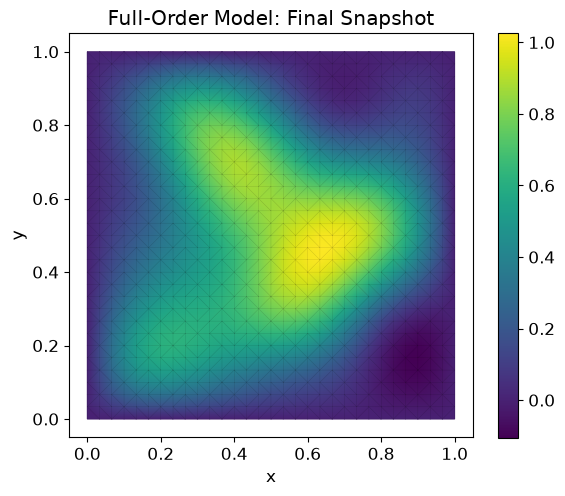

In [20]:
plot_snapshot(S[:, -1], "Full-Order Model: Final Snapshot", "snapshot_final.png")


---

# 3. Proper Orthogonal Decomposition (POD)

The objective of Proper Orthogonal Decomposition (POD) is to construct a low-dimensional basis that captures the dominant dynamics of the Full Order Model.

Since the snapshots originate from a finite element discretization, the POD basis must be orthonormal with respect to the finite element inner product.

Consequently, the finite element mass matrix is incorporated into the POD construction.

## Mass Matrix Assembly

The finite element mass matrix defines the discrete $L^2(\Omega)$ inner product

$$
(u,v)_M = u^T M v.
$$

It will be used to compute the POD basis.

In [21]:
# Trial and test functions for matrix assembly
u_trial = ufl.TrialFunction(V)
v_test = ufl.TestFunction(V)

mass_form = ufl.inner(u_trial, v_test) * ufl.dx

M = fem.petsc.assemble_matrix(
    fem.form(mass_form)
)

M.assemble()

## 3.1. Correlation Matrix

Rather than performing a Singular Value Decomposition of the snapshot matrix directly, we use the method of snapshots.

The correlation matrix is defined as

$$
C=\frac{1}{N_s}S^TMS,
$$

where

- $S$ is the snapshot matrix,
- $M$ is the finite element mass matrix,
- $N_s$ is the number of snapshots.

This approach is significantly more efficient whenever the number of snapshots is much smaller than the number of finite element degrees of freedom.

In [22]:
num_snapshots = S.shape[1]

### Conversion to a NumPy Array

The mass matrix is assembled as a PETSc sparse matrix. It is converted to a NumPy array in order to construct the correlation matrix and perform the subsequent linear algebra operations.

In [23]:
num_dofs = S.shape[0]

rows = np.arange(num_dofs, dtype=np.int32)
cols = np.arange(num_dofs, dtype=np.int32)

M_np = M.getValues(rows, cols)

C = (S.T @ M_np @ S) / num_snapshots

### Symmetry of the Correlation Matrix

The correlation matrix is symmetric by construction. Due to floating-point arithmetic, a slight loss of symmetry may occur numerically.

To ensure a symmetric eigenvalue problem, we explicitly enforce symmetry.

In [24]:
C = 0.5 * (C + C.T)

## 3.2. Eigenvalue Decomposition

The POD modes are obtained from the eigenvalue decomposition of the correlation matrix

$$
Cv_i=\lambda_i v_i.
$$

The eigenvalues are sorted in descending order since the dominant POD modes correspond to the largest energetic contributions.

In [25]:
eigenvalues, eigenvectors = np.linalg.eigh(C)
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
print(f"Number of POD modes: {len(eigenvalues)}")

Number of POD modes: 201


## 3.3. POD Basis Construction

Once the eigenvalue decomposition has been computed, the POD basis is obtained as

$$
\Phi
=
S V \Lambda^{-1/2},
$$

where

- $\Phi$ is the POD basis,
- $V$ contains the eigenvectors of the correlation matrix,
- $\Lambda$ is the diagonal matrix of the corresponding eigenvalues.

Only strictly positive eigenvalues are retained in order to avoid numerical instabilities.

In [26]:
# Keep only strictly positive eigenvalues
tolerance = 1e-10
valid = eigenvalues > tolerance
eigenvalues = eigenvalues[valid]
eigenvectors = eigenvectors[:, valid]

r = len(eigenvalues)
print(f"Retained POD modes: {r}")

Phi = (
    S
    @ eigenvectors
    @ np.diag(1.0 / np.sqrt(num_snapshots * eigenvalues))
)

Retained POD modes: 5


### Orthonormality Verification

The resulting POD basis should satisfy

$$
\Phi^T M \Phi = I.
$$

The following computation verifies this property numerically.

In [27]:
orthogonality_error = (
    Phi.T @ M_np @ Phi
    - np.eye(r)
)

print(
    "Maximum orthogonality error:",
    np.max(np.abs(orthogonality_error)),
)

Maximum orthogonality error: 1.5537458097902856e-08


## 3.4. POD Spectrum

The eigenvalues measure the amount of energy captured by each POD mode.

A rapid decay indicates that the solution can be accurately represented in a low-dimensional subspace.

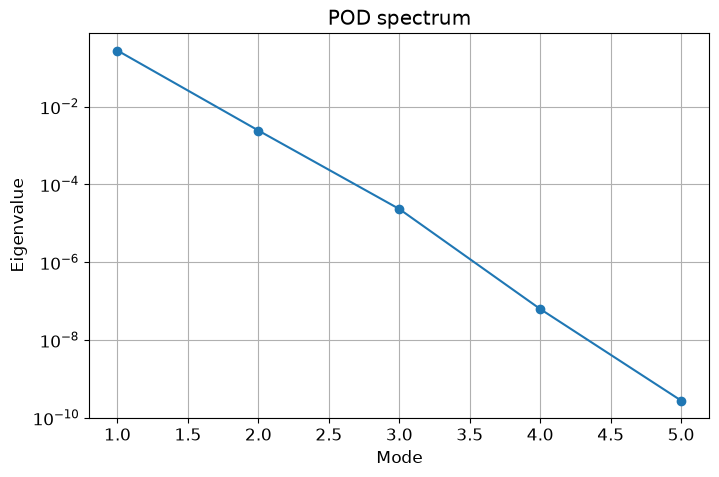

In [28]:
relative_energy = eigenvalues / np.sum(eigenvalues)
cumulative_energy = np.cumsum(relative_energy)

plt.figure()

plt.semilogy(
    np.arange(1, r + 1),
    eigenvalues,
    marker="o",
)

plt.xlabel("Mode")
plt.ylabel("Eigenvalue")
plt.title("POD spectrum")

plt.grid(True)

plt.show()

## 3.5 Truncation of the POD Basis

In practice, only the leading POD modes are retained.

The reduced basis can be selected either by specifying a fixed number of modes or by prescribing a minimum amount of captured energy.

Both strategies are supported below.

In [29]:
# ============================================
# POD truncation
# ============================================

# Strategy 1: fixed number of modes
num_modes = min(10, len(eigenvalues))
mode_to_plot = num_modes

# Strategy 2: energy criterion
energy_threshold = None  # e.g. 0.999

if energy_threshold is not None:
    cumulative_energy = np.cumsum(relative_energy)
    num_modes = np.searchsorted(cumulative_energy, energy_threshold) + 1

print(f"Number of retained POD modes: {num_modes}")

Number of retained POD modes: 5


### Energy Captured by the Reduced Basis

The cumulative energy indicates how much of the snapshot dynamics is preserved by the retained POD modes.

The selected reduced dimension is highlighted below.

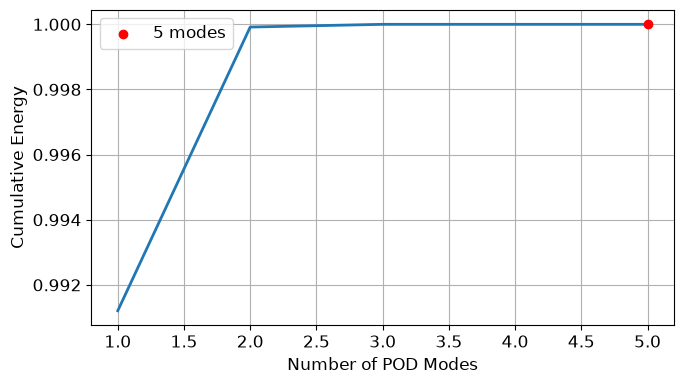

In [30]:
# If the energy criterion is not used, cumulative_energy is already available
# from the POD spectrum section. Otherwise, it has just been computed above.
if "cumulative_energy" not in globals():
    relative_energy = eigenvalues / np.sum(eigenvalues)
    cumulative_energy = np.cumsum(relative_energy)

plt.figure(figsize=(7, 4))

plt.plot(
    np.arange(1, len(cumulative_energy) + 1),
    cumulative_energy,
    lw=2,
)

plt.scatter(
    mode_to_plot,
    cumulative_energy[mode_to_plot - 1],
    color="red",
    zorder=10,
    label=f"{mode_to_plot} modes",
)

plt.xlabel("Number of POD Modes")
plt.ylabel("Cumulative Energy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The truncated POD basis is obtained by retaining only the first `num_modes` columns of the complete basis.

In [31]:
Phi_r = Phi[:, :num_modes]

## 3.6 POD Reconstruction

The truncated POD basis provides the best low-dimensional approximation of the snapshot matrix in the sense of the finite element $L^2(\Omega)$ inner product.

Each snapshot is projected onto the reduced POD basis and reconstructed as

$$
\tilde{u} = \Phi_r \Phi_r^T M u,
$$

where $\Phi_r$ denotes the truncated POD basis and $M$ is the finite element mass matrix.

This step evaluates the approximation capability of the reduced basis independently of the reduced-order model.

In [32]:
pod_coefficients = Phi_r.T @ M_np @ S
S_reconstructed = Phi_r @ pod_coefficients

## 3.7. Reconstruction Error
The reconstruction error is measured using the discrete $L^2(\Omega)$ norm induced by the finite element mass matrix.

For a snapshot $u$, the relative error is defined as

$$
\varepsilon(u)
=
\frac{
\|u-\tilde{u}\|_M
}{
\|u\|_M
},
$$

where

$$
\|u\|_M
=
\sqrt{u^T M u}.
$$

In [33]:
def relative_l2_error(reference, approximation, mass_matrix):
    """
    Compute the relative L2 error induced by the FEM mass matrix.
    """
    error = reference - approximation

    numerator = np.sqrt(error.T @ mass_matrix @ error)
    denominator = np.sqrt(reference.T @ mass_matrix @ reference)

    return numerator / denominator

reconstruction_errors = np.array(
    [
        relative_l2_error(
            S[:, i],
            S_reconstructed[:, i],
            M_np,
        )
        for i in range(num_snapshots)
    ]
)

print(f"Mean reconstruction error : {np.mean(reconstruction_errors):.3e}")
print(f"Maximum reconstruction error : {np.max(reconstruction_errors):.3e}")

Mean reconstruction error : 5.928e-06
Maximum reconstruction error : 3.143e-05


## 3.8. Error Evolution

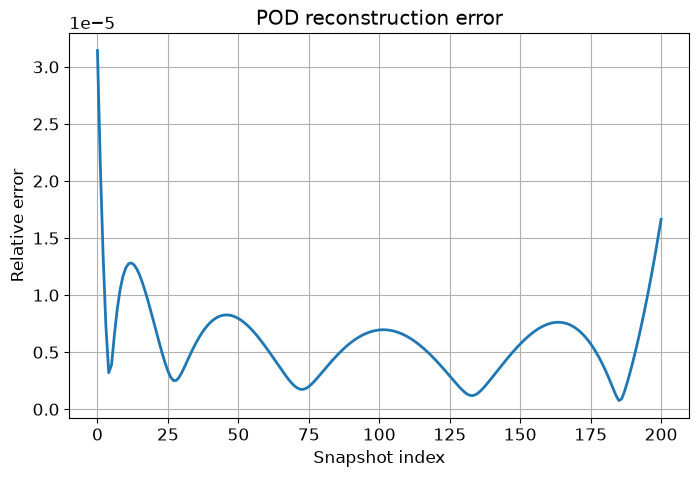

In [34]:
plt.figure()

plt.plot(
    reconstruction_errors,
    linewidth=2,
)

plt.xlabel("Snapshot index")
plt.ylabel("Relative error")

plt.title("POD reconstruction error")

plt.grid(True)

plt.show()

## 3.9. Snapshot Comparison

We now compare a representative snapshot of the Full-Order Model with its POD reconstruction.

The same snapshot is also used to display the pointwise absolute error.

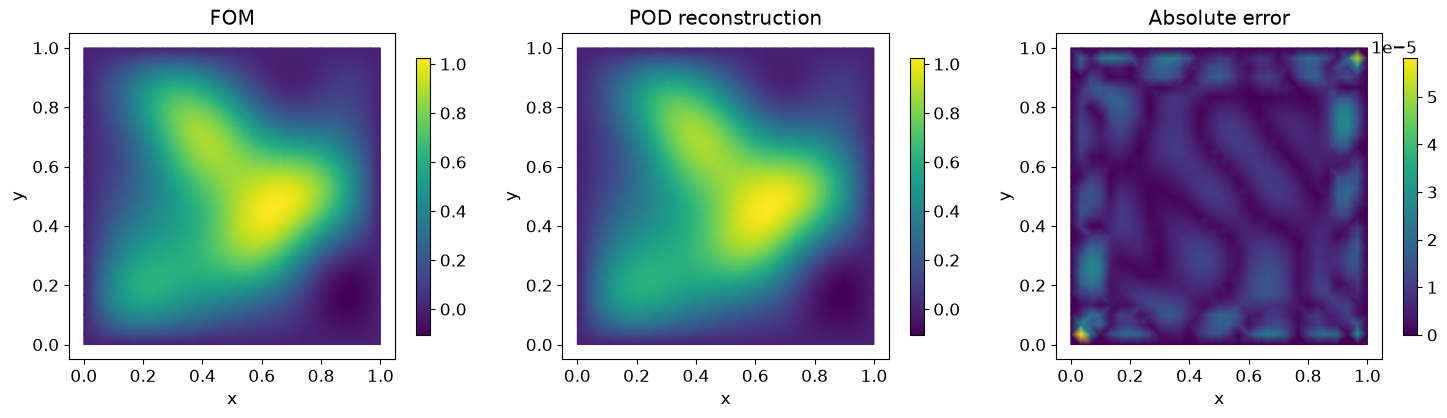

In [35]:
snapshot_id = -1  # final snapshot

u_exact = S[:, snapshot_id]
u_pod = S_reconstructed[:, snapshot_id]
u_error = np.abs(u_exact - u_pod)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full Order Model
c1 = axes[0].tripcolor(
    triangulation,
    u_exact,
    shading="gouraud",
)
axes[0].set_title("FOM")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

# POD reconstruction
c2 = axes[1].tripcolor(
    triangulation,
    u_pod,
    shading="gouraud",
)
axes[1].set_title("POD reconstruction")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

# Absolute error
c3 = axes[2].tripcolor(
    triangulation,
    u_error,
    shading="gouraud",
)
axes[2].set_title("Absolute error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

fig.colorbar(c1, ax=axes[0], shrink=0.85)
fig.colorbar(c2, ax=axes[1], shrink=0.85)
fig.colorbar(c3, ax=axes[2], shrink=0.85)

plt.tight_layout()
plt.show()


---

# 4. Galerkin Reduced-Order Model (ROM)

The finite element discretization leads to the semi-discrete dynamical system

$$
M \frac{du}{dt} + \nu K u = 0,
$$

where

- $M$ is the finite element mass matrix,
- $K$ is the finite element stiffness matrix.

The solution is approximated in the POD basis as

$$
u(t) \approx \Phi a(t),
$$

where $a(t)$ contains the reduced coordinates.

Projecting the governing equation onto the POD space yields the reduced-order model

$$
M_r \frac{da}{dt}
+
\nu K_r a
=
0,
$$

with

$$
M_r=\Phi^T M \Phi,
\qquad
K_r=\Phi^T K \Phi.
$$

The reduced matrices are now of size $r \times r,$ where $r$ is the number of retained POD modes. Since $r \ll N$, the reduced system is much cheaper to solve than the full-order system.

## Assembly of the Reduced Operator

In [36]:
# Stiffness matrix assembly
stiffness_form = ufl.inner(
    ufl.grad(u_trial),
    ufl.grad(v_test),
) * ufl.dx

K = fem.petsc.assemble_matrix(
    fem.form(stiffness_form)
)

K.assemble()

rows = np.arange(num_dofs, dtype=np.int32)
cols = np.arange(num_dofs, dtype=np.int32)

K_np = K.getValues(rows, cols)

Mr = Phi_r.T @ M_np @ Phi_r
Kr = Phi_r.T @ K_np @ Phi_r

In [37]:
print(f"Reduced dimension : {Mr.shape[0]}")

Reduced dimension : 5


## 4.1. Time Integration
The reduced system is integrated using the same backward Euler scheme as the Full Order Model.

In [38]:
Ar = Mr + dt * nu * Kr

# Initial reduced coordinates
a = Phi_r.T @ M_np @ S[:, 0]

rom_snapshots = [Phi_r @ a]

for _ in range(num_steps):

    rhs = Mr @ a

    a = np.linalg.solve(Ar, rhs)

    rom_snapshots.append(Phi_r @ a)
    

S_rom = np.column_stack(rom_snapshots)

## 4.2. Error Analysis

The reduced-order solution is compared with the Full-Order Model using the relative discrete $L^2(\Omega)$ error induced by the finite element mass matrix.

In [39]:
rom_errors = np.array(
    [
        relative_l2_error(
            S[:, i],
            S_rom[:, i],
            M_np,
        )
        for i in range(num_snapshots)
    ]
)

print(f"Mean ROM error    : {np.mean(rom_errors):.3e}")
print(f"Maximum ROM error : {np.max(rom_errors):.3e}")

Mean ROM error    : 6.518e-06
Maximum ROM error : 3.143e-05


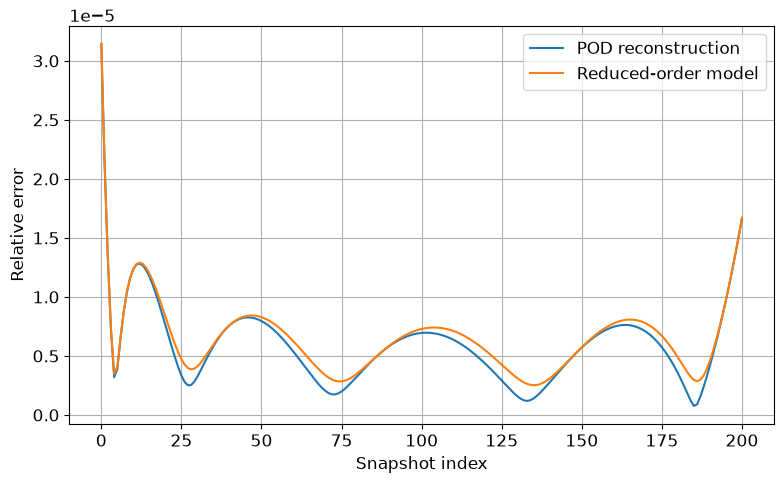

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    reconstruction_errors,
    label="POD reconstruction",
)

plt.plot(
    rom_errors,
    label="Reduced-order model",
)

plt.xlabel("Snapshot index")
plt.ylabel("Relative error")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4.3. Snapshot Comparison

We finally compare the Full-Order Model and the Reduced-Order Model for the final snapshot.

The pointwise absolute error is also displayed.

In [41]:
snapshot_id = -1

u_fom = S[:, snapshot_id]
u_rom = S_rom[:, snapshot_id]

absolute_error = np.abs(u_fom - u_rom)

vmin = min(u_fom.min(), u_rom.min())
vmax = max(u_fom.max(), u_rom.max())

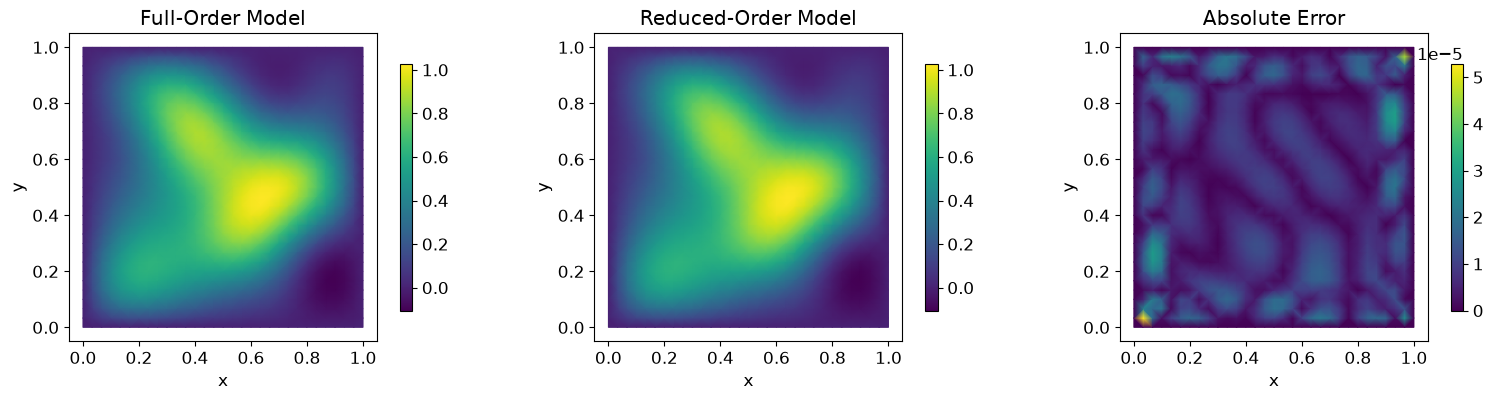

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full Order Model
fom = axes[0].tripcolor(
    triangulation,
    u_fom,
    shading="gouraud",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title("Full-Order Model")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

# Reduced Order Model
rom = axes[1].tripcolor(
    triangulation,
    u_rom,
    shading="gouraud",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title("Reduced-Order Model")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

# Absolute error
err = axes[2].tripcolor(
    triangulation,
    absolute_error,
    shading="gouraud",
)

axes[2].set_title("Absolute Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

fig.colorbar(fom, ax=axes[0], shrink=0.8)
fig.colorbar(rom, ax=axes[1], shrink=0.8)
fig.colorbar(err, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

## 4.4. Performance

We compare the computational cost of the Full-Order Model and the Reduced-Order Model.

The reported timings only include the time-stepping loops and exclude post-processing.

In [43]:
start_fom = time.perf_counter()

snapshots_fom_timed = []
u_prev.interpolate(initial_condition)
u_prev.x.scatter_forward()
snapshots_fom_timed.append(solution_vector(u_prev))

for step in range(1, num_steps + 1):
    problem.solve()
    snapshots_fom_timed.append(solution_vector(u_curr))
    u_prev.x.array[:] = u_curr.x.array
    u_prev.x.scatter_forward()

fom_time = time.perf_counter() - start_fom

In [44]:
start_rom = time.perf_counter()

a = Phi_r.T @ M_np @ S[:, 0]
rom_snapshots_timed = [Phi_r @ a]

for step in range(1, num_steps + 1):
    rhs = Mr @ a
    a = np.linalg.solve(Ar, rhs)
    rom_snapshots_timed.append(Phi_r @ a)

rom_time = time.perf_counter() - start_rom

In [45]:
speedup = fom_time / rom_time if rom_time > 0 else np.inf

print(f"FOM time   : {fom_time:.4f} s")
print(f"ROM time   : {rom_time:.4f} s")
print(f"Speed-up : ×{speedup:.2f}")

FOM time   : 0.2646 s
ROM time   : 0.0327 s
Speed-up : ×8.09
